In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

d:\mynew\demo_all


### 生成不同mueextmean的npy, 已将慢纺锤调至慢波的后半周期以后
- 找不到什么规律，所以再次将Jrt=-0.7之后看看情况

In [2]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

def run_parameter_sweep(config):
    """
    运行参数扫描
    config: 字典，包含所有参数
    """
    # 解包配置
    n_runs = config['n_runs']
    c2tsc = config['c2tsc']              # 定值
    scale2 = config['scale2']            # 定值
    param_name = config['param_name']    # 要扫描的参数名
    param_list = config['param_list']    # 要扫描的参数值列表
    data_dir = config['data_dir']        # 保存目录
    
    # 创建保存目录
    os.makedirs(data_dir, exist_ok=True)
    
    # 统计已完成文件（跳过已存在的）
    existing_files = set()
    for f in os.listdir(data_dir):
        if f.endswith(".npy"):
            existing_files.add(f)
    
    total_tasks = len(param_list) * n_runs
    completed = len([f for f in existing_files if param_name in f])
    print(f"总任务数: {total_tasks}, 已完成: {completed}, 待运行: {total_tasks - completed}")
    
    for param_val in param_list:
        for seed in range(1, n_runs + 1):
            # 生成文件名
            filename = f"c2tsc_{c2tsc:.4f}_scale2_{scale2:.4f}_{param_name}_{param_val:.4f}_seed_{seed}.npy"
            save_path = os.path.join(data_dir, filename)
            
            # 如果文件已存在，跳过
            if filename in existing_files:
                print(f"跳过: {filename}")
                continue
            
            # 加载默认参数并修改
            params = dp.loadDefaultParams(seed)
            #params["c2tsc"] = c2tsc
            #params["scale2"] = scale2
            params["mue_ext_mean"] = param_val #这里一定要把正确的参数改掉

            params["Jet"] = 78.2 #18 * 0.8 #1.98
            params["Jer"] = 162 #0.23 * 0.8 #3.24
            params["c2tsc"] = 0.8
            params["scale2"] = 0.0005 #0.0013

            a = 8.4 #9.5
            params["VT_t"] = 26 -a#26 -9
            params["VT_r"] = 23 -a#23
            params["VB_t"] = 15 -a#15
            params["VB_r"] = 15 -a#15
            params["Jrt"] = -0.7 #-0.6 #-1.5 # -0.5
                        
            # 运行模型
            try:
                t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
            except Exception as e:
                print(f"模型运行失败: {filename}, 错误: {e}")
                continue
            
            # 保存 raw 信号
            np.save(save_path, {
                "t": t, "V_e": V_e, "V_i": V_i, 
                "Q_e": Q_e, "Q_i": Q_i, 
                "V_t": V_t, "V_r": V_r, 
                "Q_t": Q_t, "Q_r": Q_r,
                "c2tsc": c2tsc,
                "scale2": scale2,
                param_name: param_val,
                "seed": seed
            })
            print(f"Saved: {param_name}={param_val:.4f}, seed={seed}")

# ========== 使用示例 ==========

# 示例1：扫描 mue_ext_mean
config_mue = {
    'n_runs': 20,
    'c2tsc': 1,
    'scale2': 0.0005,
    'param_name': 'mueextmean',
    'param_list': np.linspace(1.5,3.3,19),
    'data_dir': "data/raw_data_explore_mueextmean_slow_c2tsc0x7",
}





# 运行（取消注释需要的）
run_parameter_sweep(config_mue)

总任务数: 380, 已完成: 0, 待运行: 380
Saved: mueextmean=1.5000, seed=1
Saved: mueextmean=1.5000, seed=2
Saved: mueextmean=1.5000, seed=3
Saved: mueextmean=1.5000, seed=4
Saved: mueextmean=1.5000, seed=5
Saved: mueextmean=1.5000, seed=6
Saved: mueextmean=1.5000, seed=7
模型运行失败: c2tsc_1.0000_scale2_0.0005_mueextmean_1.5000_seed_8.npy, 错误: Unable to allocate 2.29 MiB for an array with shape (300000,) and data type float64


KeyboardInterrupt: 

In [ ]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/mueextmean for20251128_11:10isdone')


### spindles for param analysis (spindles_param_explore_valid_limited.csv)
- param = mue_ext_mean_slow
- c2tsc = 1; scale2 = 0.0005 / c2tsc = 0.8; scale2 = 0.0005 /c2tsc = 0.8; scale2 = 0.0005
- param -> fast/slow spindles -> wax & wane

### 区分wax&wane之后

In [ ]:
import numpy as np
import pandas as pd
import yasa
import glob
from scipy.signal import hilbert
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import os

# ========== 只需要改这两行 ==========
DATA_FOLDER = "mueextmean_slow_c2tsc0x7"      # 数据文件夹名
PARAM_NAME = "mueextmean_slow_c2tsc0x7"       # 参数名
PARAM_RANGE = (1.5, 3.3)                      # 参数范围 (min, max)
# =================================

RAW_DATA_DIR = f"data/raw_data_explore_{DATA_FOLDER}"
OUTPUT_PREFIX = f"spindles_{DATA_FOLDER}"

def get_phase_and_envelope(signal, filter_args, pad=None):
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(how_much=pad, in_seconds=True, padding_type="reflect", side="both")
    phase.filter(**filter_args)
    filtered = phase.data.values.copy()
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    analytic = hilbert(filtered)
    envelope = np.abs(analytic)
    return phase.data.values, filtered, envelope

def process_spindles(sp, spindle_type, params, t_mid, sf, t_min, t_max, envelope, slow_phase_masked, V_t=None):
    """
    处理纺锤波检测结果
    新增：从原始 V_t 中提取 start→peak 和 peak→end 的振幅
    """
    results = []
    if sp is None:
        return results
    
    df = sp.summary()
    for _, row in df.iterrows():
        start_time = row["Start"]
        peak_time = row["Peak"]
        end_time = row["End"]
        overall_amplitude = row["Amplitude"]  # YASA 计算的整体振幅
        
        start_idx_sample = int(start_time * sf)
        peak_idx_sample = int(peak_time * sf)
        end_idx_sample = int(end_time * sf)
        
        if not (t_min <= start_idx_sample <= t_max and t_min <= end_idx_sample <= t_max):
            continue
        
        start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
        peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
        end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
        
        # ===== 从原始 V_t 中计算 start→peak 和 peak→end 的振幅 =====
        # 截取信号片段
        start_segment = V_t[start_idx_sample:peak_idx_sample] if peak_idx_sample > start_idx_sample else np.array([0])
        end_segment = V_t[peak_idx_sample:end_idx_sample] if end_idx_sample > peak_idx_sample else np.array([0])
        
        # 计算各段的最大振幅（峰峰值：最大值 - 最小值）
        # 如果段长度小于2，直接用该点的值
        if len(start_segment) >= 2:
            start_to_peak_amp = np.max(start_segment) - np.min(start_segment)
        else:
            start_to_peak_amp = 0.0
        
        if len(end_segment) >= 2:
            peak_to_end_amp = np.max(end_segment) - np.min(end_segment)
        else:
            peak_to_end_amp = 0.0
        
        # 或者用 RMS 振幅（更稳定，但峰峰值更常用）
        # start_to_peak_amp = np.sqrt(np.mean(start_segment**2)) if len(start_segment) > 0 else 0
        
        phase_start = slow_phase_masked[start_idx]
        phase_peak = slow_phase_masked[peak_idx]
        phase_end = slow_phase_masked[end_idx]
        
        results.append({
            **params,
            "type": spindle_type,
            "start": start_time,
            "peak_time": peak_time,
            "end": end_time,
            "duration": row["Duration"],
            "frequency": row["Frequency"],
            "amplitude": overall_amplitude,              # 原有的整体振幅
            "start_to_peak_time": peak_time - start_time,
            "peak_to_end_time": end_time - peak_time,
            "start_to_peak_amp": start_to_peak_amp,      # 新增：上升段振幅
            "peak_to_end_amp": peak_to_end_amp,          # 新增：下降段振幅
            "phase_at_start": phase_start,
            "phase_at_peak": phase_peak,
            "phase_at_end": phase_end,
            "envelope_at_start": envelope[start_idx],
            "envelope_at_peak": envelope[peak_idx],
            "envelope_at_end": envelope[end_idx],
            "masked": np.isnan(phase_peak),
        })
    return results

# ========== 主程序 ==========
sf = 10000
remove_edges_samples = 20000
SW = {"low_freq": None, "high_freq": 3.0}
amplitude_threshold = 2

file_list = glob.glob(os.path.join(RAW_DATA_DIR, "*.npy"))
print(f"找到 {len(file_list)} 个文件")
print(f"限定 {PARAM_NAME} 范围: {PARAM_RANGE}")
print(f"输出前缀: {OUTPUT_PREFIX}")

all_spindles = []

for file_path in file_list:
    file_path = file_path.replace("\\", "/")
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    
    c2tsc = float(parts[1])
    scale2 = float(parts[3])
    param_val = float(parts[5])
    seed = int(parts[7])
    
    if not (PARAM_RANGE[0] <= param_val <= PARAM_RANGE[1]):
        continue
    
    print(f"Processing: {PARAM_NAME}={param_val:.4f}, seed={seed}")
    
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    results_df = pd.DataFrame({"ALN": V_e_mid}, index=t_mid / sf)
    results_df.index.name = "time"
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    slow_phase, V_slow, envelope = get_phase_and_envelope(aln_sig, filter_args=SW, pad=0.0)
    
    mask_amplitude = envelope > amplitude_threshold
    slow_phase_masked = slow_phase.copy()
    slow_phase_masked[~mask_amplitude] = np.nan
    
    params = {PARAM_NAME: param_val, "c2tsc": c2tsc, "scale2": scale2, "seed": seed}
    
    # 传入 V_t 用于计算分段振幅
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12,16), duration=(0.3,2))
    all_spindles.extend(process_spindles(sp_fast, "fast", params, t_mid, sf, t_min, t_max, envelope, slow_phase_masked, V_t))
    
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8,12), duration=(0.3,2))
    all_spindles.extend(process_spindles(sp_slow, "slow", params, t_mid, sf, t_min, t_max, envelope, slow_phase_masked, V_t))
    
    print(f"  完成")

os.makedirs("data/analysis_data", exist_ok=True)
result_df = pd.DataFrame(all_spindles)
result_df.to_csv(f"data/analysis_data/{OUTPUT_PREFIX}_explore_limited.csv", index=False)

result_df_valid = result_df[~result_df['masked']].copy()
result_df_valid.to_csv(f"data/analysis_data/{OUTPUT_PREFIX}_explore_valid_limited.csv", index=False)

print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(f"相位有效: {len(result_df_valid)} 个")

# 打印新增字段示例
if len(result_df) > 0:
    print("\n新增字段示例（第一条记录）:")
    cols = ['start_to_peak_time', 'peak_to_end_time', 'start_to_peak_amp', 'peak_to_end_amp', 'amplitude']
    for col in cols:
        if col in result_df.columns:
            print(f"  {col}: {result_df[col].iloc[0]:.6f}")

找到 380 个文件
限定 mueextmean_slow_c2tsc0x8 范围: (1.5, 3.3)
输出前缀: spindles_mueextmean_slow_c2tsc0x8
Processing: mueextmean_slow_c2tsc0x8=1.5000, seed=1
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成
Processing: mueextmean_slow_c2tsc0x8=1.5000, seed=10
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


  完成
Processing: mueextmean_slow_c2tsc0x8=1.5000, seed=11
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz


...

  完成
Processing: mueextmean_slow_c2tsc0x8=3.3000, seed=8
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成
Processing: mueextmean_slow_c2tsc0x8=3.3000, seed=9
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成

总共检测到 4342 个纺锤波
相位有效: 2976 个

新增字段示例（第一条记录）:
  start_to_peak_time: 0.180100
  peak_to_end_time: 0.300400
  start_to_peak_amp: 4.728002
  peak_to_end_amp: 3.629363
  amplitude: 4.043038


### 画图 wax & wane

加载文件: spindles_mueextmean_slow_c2tsc0x8_explore_valid_limited.csv
分析参数: mueextmean_slow_c2tsc0x8
mueextmean_slow_c2tsc0x8 值: [1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3]

按 seed 统计后的结果示例:
   mueextmean_slow_c2tsc0x8  seed  type  total_duration  count  mean_freq  \
0                       1.5     2  fast          1.1596      2  12.920803   
1                       1.5     2  slow          3.1685      6  10.590792   
2                       1.5     3  fast          1.1196      2  12.679434   
3                       1.5     3  slow          3.8528      3  11.308521   
4                       1.5     4  slow          2.9495      4  10.662040   

   std_freq  mean_duration  std_duration  mean_start_to_peak_time  \
0  0.428060       0.579800      0.358503                 0.343100   
1  0.466488       0.528083      0.292518                 0.257800   
2  0.496947       0.559800      0.217647                 0.192500   
3  0.238652       1.28

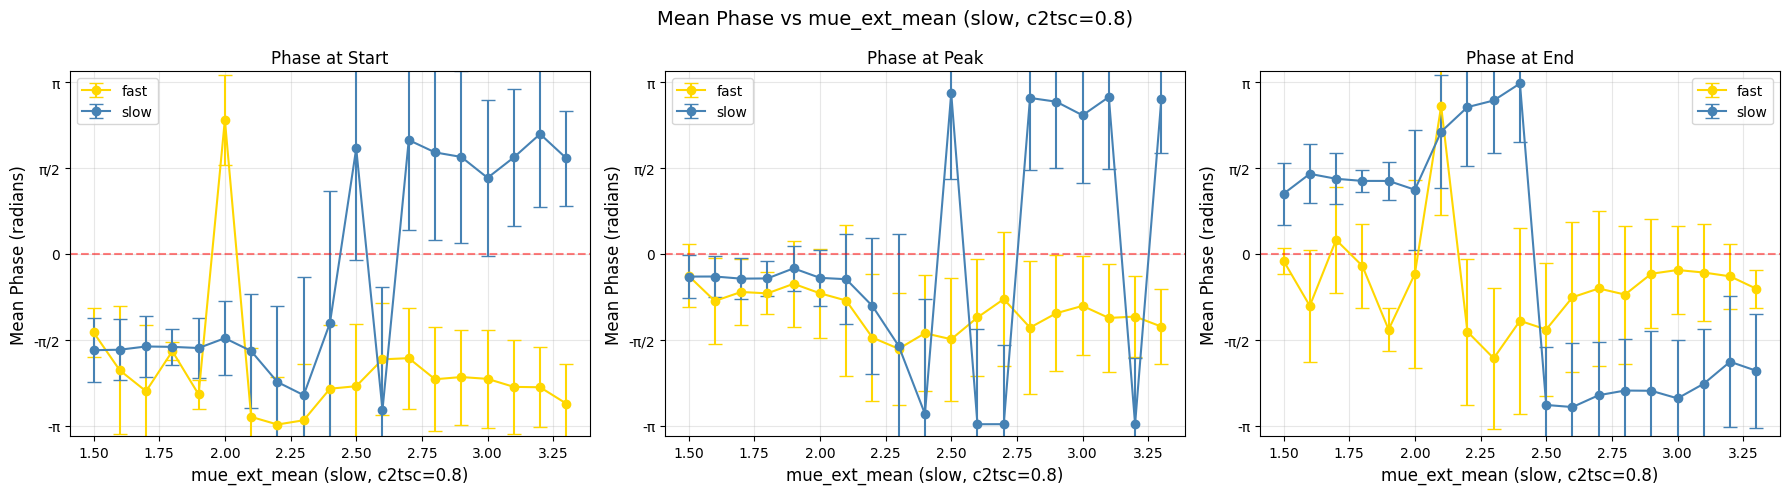

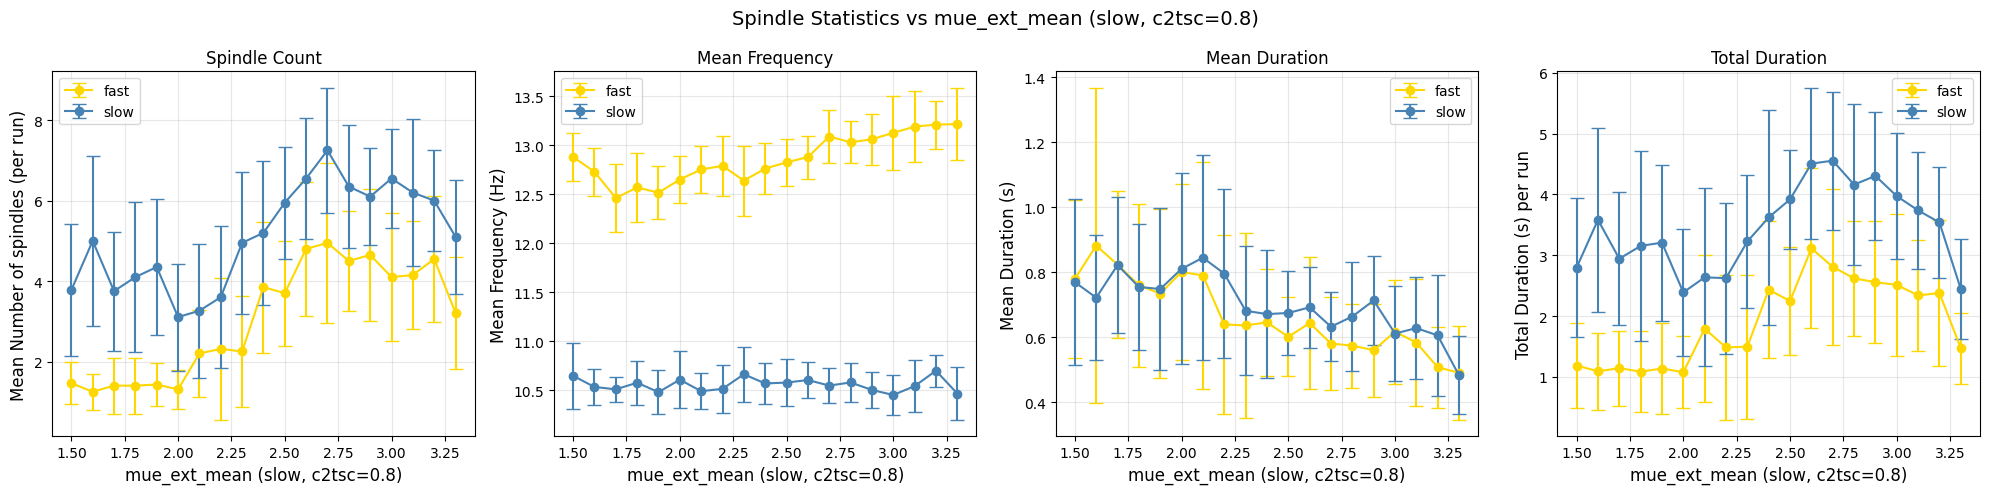

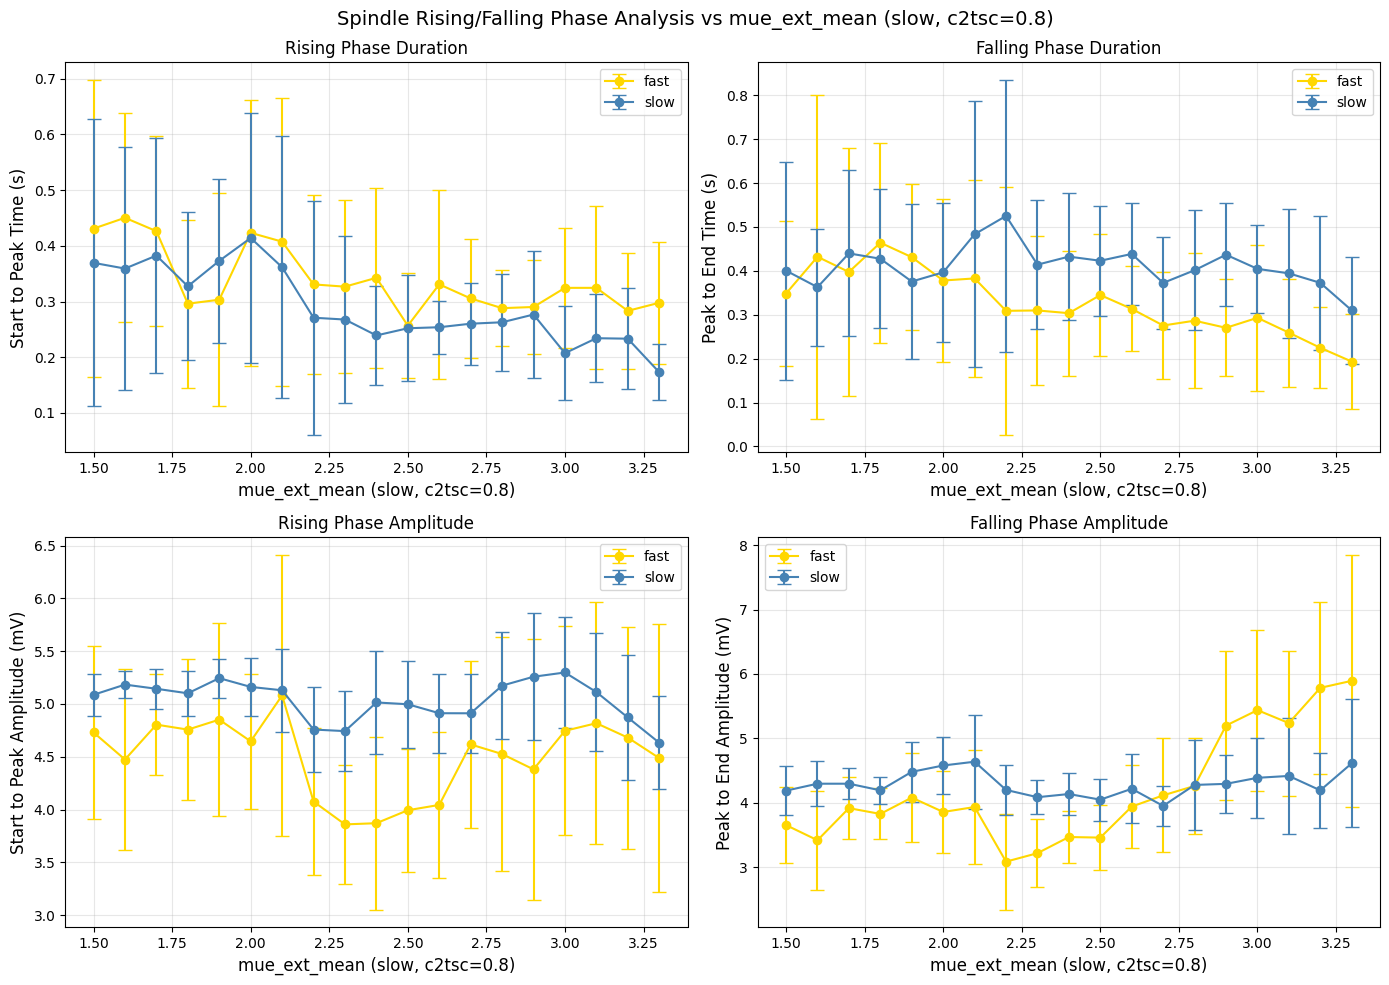


统计摘要（每个 seed 先统计，再对 seed 平均）

FAST 纺锤波:
  mueextmean_slow_c2tsc0x8=1.50: seeds=13, count=1.5±0.5, rise_time=0.431±0.267s, fall_time=0.348±0.165s, rise_amp=4.730±0.822mV, fall_amp=3.652±0.594mV, phase=-0.401±0.579rad
  mueextmean_slow_c2tsc0x8=1.60: seeds=12, count=1.2±0.5, rise_time=0.450±0.187s, fall_time=0.432±0.369s, rise_amp=4.474±0.855mV, fall_amp=3.417±0.767mV, phase=-0.862±0.779rad
  mueextmean_slow_c2tsc0x8=1.70: seeds=10, count=1.4±0.7, rise_time=0.426±0.170s, fall_time=0.397±0.282s, rise_amp=4.804±0.475mV, fall_amp=3.915±0.486mV, phase=-0.697±0.605rad
  mueextmean_slow_c2tsc0x8=1.80: seeds=10, count=1.4±0.7, rise_time=0.296±0.151s, fall_time=0.464±0.228s, rise_amp=4.757±0.664mV, fall_amp=3.825±0.397mV, phase=-0.722±0.383rad
  mueextmean_slow_c2tsc0x8=1.90: seeds= 7, count=1.4±0.5, rise_time=0.303±0.191s, fall_time=0.431±0.167s, rise_amp=4.851±0.911mV, fall_amp=4.079±0.697mV, phase=-0.547±0.788rad
  mueextmean_slow_c2tsc0x8=2.00: seeds=13, count=1.3±0.5, rise_time=0.423±0.239

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 只需要改这一个参数 ==========
PARAM_TYPE = "mueextmean_slow_c2tsc0x7"   # 可选: "mue_ext_mean", "tau_ou", "tau_se", "cee"
# ======================================

# 根据 PARAM_TYPE 自动生成所有配置
PARAM_CONFIG = {
    "mueextmean": {
        "file": "spindles_mueextmean_explore_valid_limited.csv",
        "xlabel": "mueextmean",
        "save_prefix": "mueextmean",
    },
    "mueextmean_slow": {
        "file": "spindles_mueextmean_slow_explore_valid_limited.csv",
        "xlabel": "mue_ext_mean (slow)",
        "save_prefix": "mue_ext_mean_slow",
    },
    "mueextmean_slow_c2tsc0x8": {
        "file": "spindles_mueextmean_slow_c2tsc0x8_explore_valid_limited.csv",
        "xlabel": "mue_ext_mean (slow, c2tsc=0.8)",
        "save_prefix": "mue_ext_mean_slow_c2tsc0x8",
    },
    "tau_ou": {
        "file": "spindles_tau_ou_explore_valid_limited.csv",
        "xlabel": "tau_ou (ms)",
        "save_prefix": "tau_ou",
    },
    "tau_se": {
        "file": "spindles_tau_se_explore_valid_limited.csv",
        "xlabel": "tau_se (ms)",
        "save_prefix": "tau_se",
    },
    "cee": {
        "file": "spindles_cee_explore_valid_limited.csv",
        "xlabel": "cee",
        "save_prefix": "cee",
    },
}

# 获取当前配置
config = PARAM_CONFIG[PARAM_TYPE]
DATA_FILE = config["file"]
X_LABEL = config["xlabel"]
SAVE_PREFIX = config["save_prefix"]
PARAM_NAME = PARAM_TYPE

print(f"加载文件: {DATA_FILE}")
print(f"分析参数: {PARAM_NAME}")

# ========== 以下代码完全不用改 ==========
df = pd.read_csv(f"data/analysis_data/{DATA_FILE}")

phase_columns = ['phase_at_start', 'phase_at_peak', 'phase_at_end']
phase_labels = ['Start', 'Peak', 'End']
colors = {'fast': 'gold', 'slow': 'steelblue'}

param_values = sorted(df[PARAM_NAME].unique())
print(f"{PARAM_NAME} 值: {param_values}")

def circular_stats(phases):
    if hasattr(phases, 'dropna'):
        phase_clean = phases.dropna().values
    else:
        phase_clean = phases[~np.isnan(phases)]
    if len(phase_clean) == 0:
        return np.nan, np.nan, 0
    mean_phase = circmean(phase_clean, low=-np.pi, high=np.pi)
    std_phase = circstd(phase_clean, low=-np.pi, high=np.pi)
    return mean_phase, std_phase, len(phase_clean)

# ========== 先计算每个 seed 的统计量，再求平均 ==========
# 按参数值和 seed 分组，计算每个 seed 的统计量（包括新的字段）
seed_stats = df.groupby([PARAM_NAME, 'seed', 'type']).agg(
    total_duration=('duration', 'sum'),
    count=('duration', 'size'),
    mean_freq=('frequency', 'mean'),
    std_freq=('frequency', 'std'),
    mean_duration=('duration', 'mean'),
    std_duration=('duration', 'std'),
    # ===== 新增：上升段和下降段的时间与振幅 =====
    mean_start_to_peak_time=('start_to_peak_time', 'mean'),
    std_start_to_peak_time=('start_to_peak_time', 'std'),
    mean_peak_to_end_time=('peak_to_end_time', 'mean'),
    std_peak_to_end_time=('peak_to_end_time', 'std'),
    mean_start_to_peak_amp=('start_to_peak_amp', 'mean'),
    std_start_to_peak_amp=('start_to_peak_amp', 'std'),
    mean_peak_to_end_amp=('peak_to_end_amp', 'mean'),
    std_peak_to_end_amp=('peak_to_end_amp', 'std'),
).reset_index()

# 再按参数值和类型分组，计算所有 seed 的均值和标准差
summary_stats = seed_stats.groupby([PARAM_NAME, 'type']).agg(
    mean_total_duration=('total_duration', 'mean'),
    std_total_duration=('total_duration', 'std'),
    mean_count=('count', 'mean'),
    std_count=('count', 'std'),
    mean_freq=('mean_freq', 'mean'),
    std_freq_mean=('mean_freq', 'std'),
    mean_duration=('mean_duration', 'mean'),
    std_duration_mean=('mean_duration', 'std'),
    # ===== 新增：上升段和下降段的时间与振幅 =====
    mean_start_to_peak_time=('mean_start_to_peak_time', 'mean'),
    std_start_to_peak_time=('mean_start_to_peak_time', 'std'),
    mean_peak_to_end_time=('mean_peak_to_end_time', 'mean'),
    std_peak_to_end_time=('mean_peak_to_end_time', 'std'),
    mean_start_to_peak_amp=('mean_start_to_peak_amp', 'mean'),
    std_start_to_peak_amp=('mean_start_to_peak_amp', 'std'),
    mean_peak_to_end_amp=('mean_peak_to_end_amp', 'mean'),
    std_peak_to_end_amp=('mean_peak_to_end_amp', 'std'),
).reset_index()

print("\n按 seed 统计后的结果示例:")
print(seed_stats.head())
print("\n汇总统计示例:")
print(summary_stats.head())

# ========== 图1：平均相位 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (col, label) in enumerate(zip(phase_columns, phase_labels)):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = df[df['type'] == spindle_type]
        means, stds, vals = [], [], []
        for val in param_values:
            phases = subset[subset[PARAM_NAME] == val][col].dropna().values
            if len(phases) > 0:
                mean_p, std_p, _ = circular_stats(phases)
                means.append(mean_p)
                stds.append(std_p)
                vals.append(val)
        if len(vals) > 0:
            ax.errorbar(vals, means, yerr=stds, fmt='o-', capsize=5,
                        color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Mean Phase (radians)', fontsize=12)
    ax.set_title(f'Phase at {label}', fontsize=12)
    ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle(f'Mean Phase vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图2：四张汇总图（数量、频率、时长、总时长）==========
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 子图1：平均纺锤波数量
ax = axes[0]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_count'], yerr=subset['std_count'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Number of spindles (per run)', fontsize=12)
ax.set_title('Spindle Count', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图2：平均频率
ax = axes[1]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_freq'], yerr=subset['std_freq_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Frequency (Hz)', fontsize=12)
ax.set_title('Mean Frequency', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图3：平均时长
ax = axes[2]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_duration'], yerr=subset['std_duration_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Duration (s)', fontsize=12)
ax.set_title('Mean Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图4：总时长
ax = axes[3]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_total_duration'], yerr=subset['std_total_duration'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Total Duration (s) per run', fontsize=12)
ax.set_title('Total Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Spindle Statistics vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图3：新增四张子图（上升段时间、下降段时间、上升段振幅、下降段振幅）==========
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 子图1：上升段时间 (start_to_peak_time)
ax = axes[0]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_start_to_peak_time'], 
                yerr=subset['std_start_to_peak_time'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Start to Peak Time (s)', fontsize=12)
ax.set_title('Rising Phase Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图2：下降段时间 (peak_to_end_time)
ax = axes[1]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_peak_to_end_time'], 
                yerr=subset['std_peak_to_end_time'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Peak to End Time (s)', fontsize=12)
ax.set_title('Falling Phase Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图3：上升段振幅 (start_to_peak_amp)
ax = axes[2]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_start_to_peak_amp'], 
                yerr=subset['std_start_to_peak_amp'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Start to Peak Amplitude (mV)', fontsize=12)
ax.set_title('Rising Phase Amplitude', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图4：下降段振幅 (peak_to_end_amp)
ax = axes[3]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_peak_to_end_amp'], 
                yerr=subset['std_peak_to_end_amp'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Peak to End Amplitude (mV)', fontsize=12)
ax.set_title('Falling Phase Amplitude', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Spindle Rising/Falling Phase Analysis vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 打印统计摘要 ==========
print("\n" + "="*60)
print("统计摘要（每个 seed 先统计，再对 seed 平均）")
print("="*60)

for spindle_type in ['fast', 'slow']:
    print(f"\n{spindle_type.upper()} 纺锤波:")
    for val in param_values:
        subset = seed_stats[(seed_stats[PARAM_NAME] == val) & (seed_stats['type'] == spindle_type)]
        if len(subset) > 0:
            n_seeds = len(subset)
            mean_count = subset['count'].mean()
            std_count = subset['count'].std()
            mean_total_dur = subset['total_duration'].mean()
            std_total_dur = subset['total_duration'].std()
            mean_freq = subset['mean_freq'].mean()
            std_freq = subset['mean_freq'].std()
            mean_dur = subset['mean_duration'].mean()
            std_dur = subset['mean_duration'].std()
            # 新增统计
            mean_rise_time = subset['mean_start_to_peak_time'].mean()
            std_rise_time = subset['mean_start_to_peak_time'].std()
            mean_fall_time = subset['mean_peak_to_end_time'].mean()
            std_fall_time = subset['mean_peak_to_end_time'].std()
            mean_rise_amp = subset['mean_start_to_peak_amp'].mean()
            std_rise_amp = subset['mean_start_to_peak_amp'].std()
            mean_fall_amp = subset['mean_peak_to_end_amp'].mean()
            std_fall_amp = subset['mean_peak_to_end_amp'].std()
            
            # 相位统计（仍用原始数据）
            phases = df[(df[PARAM_NAME] == val) & (df['type'] == spindle_type)]['phase_at_peak'].dropna().values
            if len(phases) > 0:
                mean_phase, std_phase, _ = circular_stats(phases)
                print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, "
                      f"rise_time={mean_rise_time:.3f}±{std_rise_time:.3f}s, fall_time={mean_fall_time:.3f}±{std_fall_time:.3f}s, "
                      f"rise_amp={mean_rise_amp:.3f}±{std_rise_amp:.3f}mV, fall_amp={mean_fall_amp:.3f}±{std_fall_amp:.3f}mV, "
                      f"phase={mean_phase:6.3f}±{std_phase:.3f}rad")
            else:
                print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, "
                      f"rise_time={mean_rise_time:.3f}±{std_rise_time:.3f}s, fall_time={mean_fall_time:.3f}±{std_fall_time:.3f}s, "
                      f"rise_amp={mean_rise_amp:.3f}±{std_rise_amp:.3f}mV, fall_amp={mean_fall_amp:.3f}±{std_fall_amp:.3f}mV, "
                      f"no valid phase")

### 画图

加载文件: spindles_mueextmean_explore_valid_limited.csv
分析参数: mueextmean
mueextmean 值: [1.4, 1.4643, 1.5286, 1.5929, 1.6571, 1.7214, 1.7857, 1.85, 1.9143, 1.9786, 2.0429, 2.1071, 2.1714, 2.2357, 2.3, 2.3571, 2.4143, 2.4714, 2.5286, 2.5857, 2.6429, 2.7, 2.7571, 2.8143, 2.8714, 2.9286, 2.9857, 3.0429, 3.1, 3.2071, 3.3143, 3.4214, 3.5286, 3.6357, 3.7429, 3.85, 3.9571, 4.0643, 4.1714, 4.2786, 4.3857, 4.4929, 4.6]


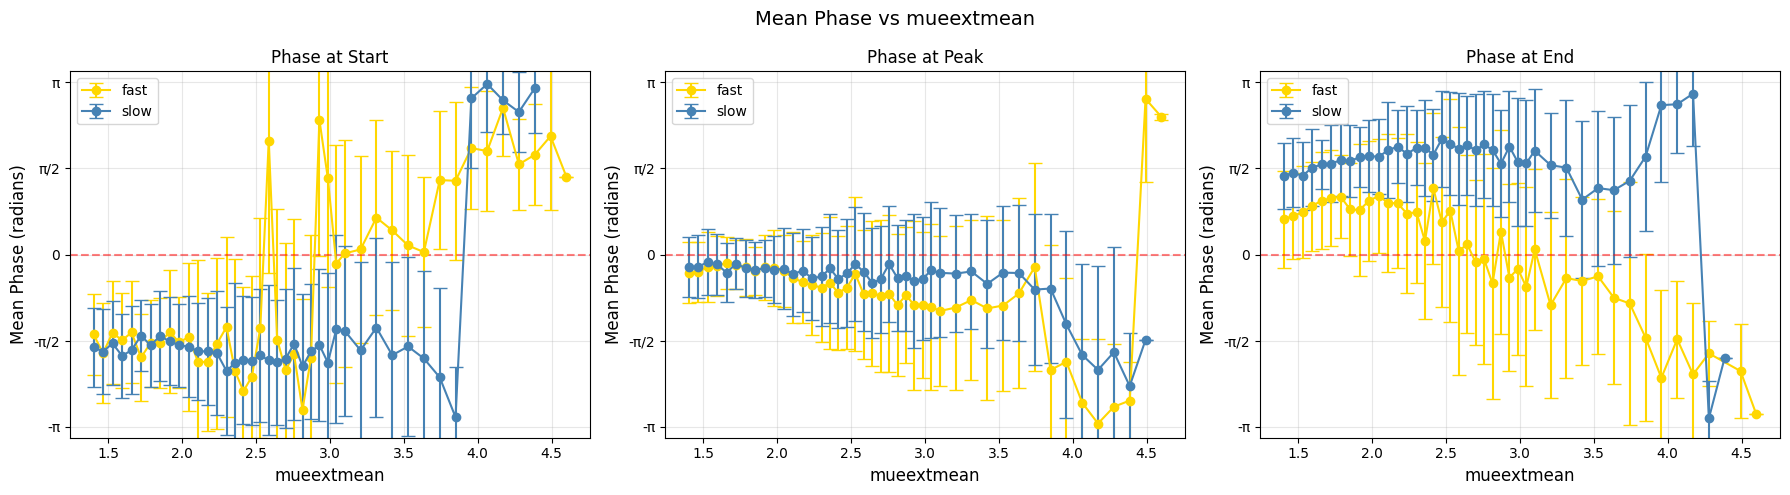


按 seed 统计后的结果示例:
   mueextmean  seed  type  total_duration  count  mean_freq  std_freq  \
0         1.4     1  fast          3.0230      5  13.288183  0.202393   
1         1.4     1  slow          2.6511      3  10.783782  0.370101   
2         1.4     2  fast          3.1521      4  12.601454  0.306260   
3         1.4     2  slow          3.4330      5  11.399272  0.608901   
4         1.4     3  fast          4.7722      6  12.428915  0.275220   

   mean_duration  std_duration  
0       0.604600      0.294453  
1       0.883700      0.507597  
2       0.788025      0.284435  
3       0.686600      0.675367  
4       0.795367      0.345914  

汇总统计示例:
   mueextmean  type  mean_total_duration  std_total_duration  mean_count  \
0      1.4000  fast             4.237340            1.183136        5.85   
1      1.4000  slow             3.985675            1.001956        5.85   
2      1.4643  fast             3.819525            1.127215        5.45   
3      1.4643  slow             

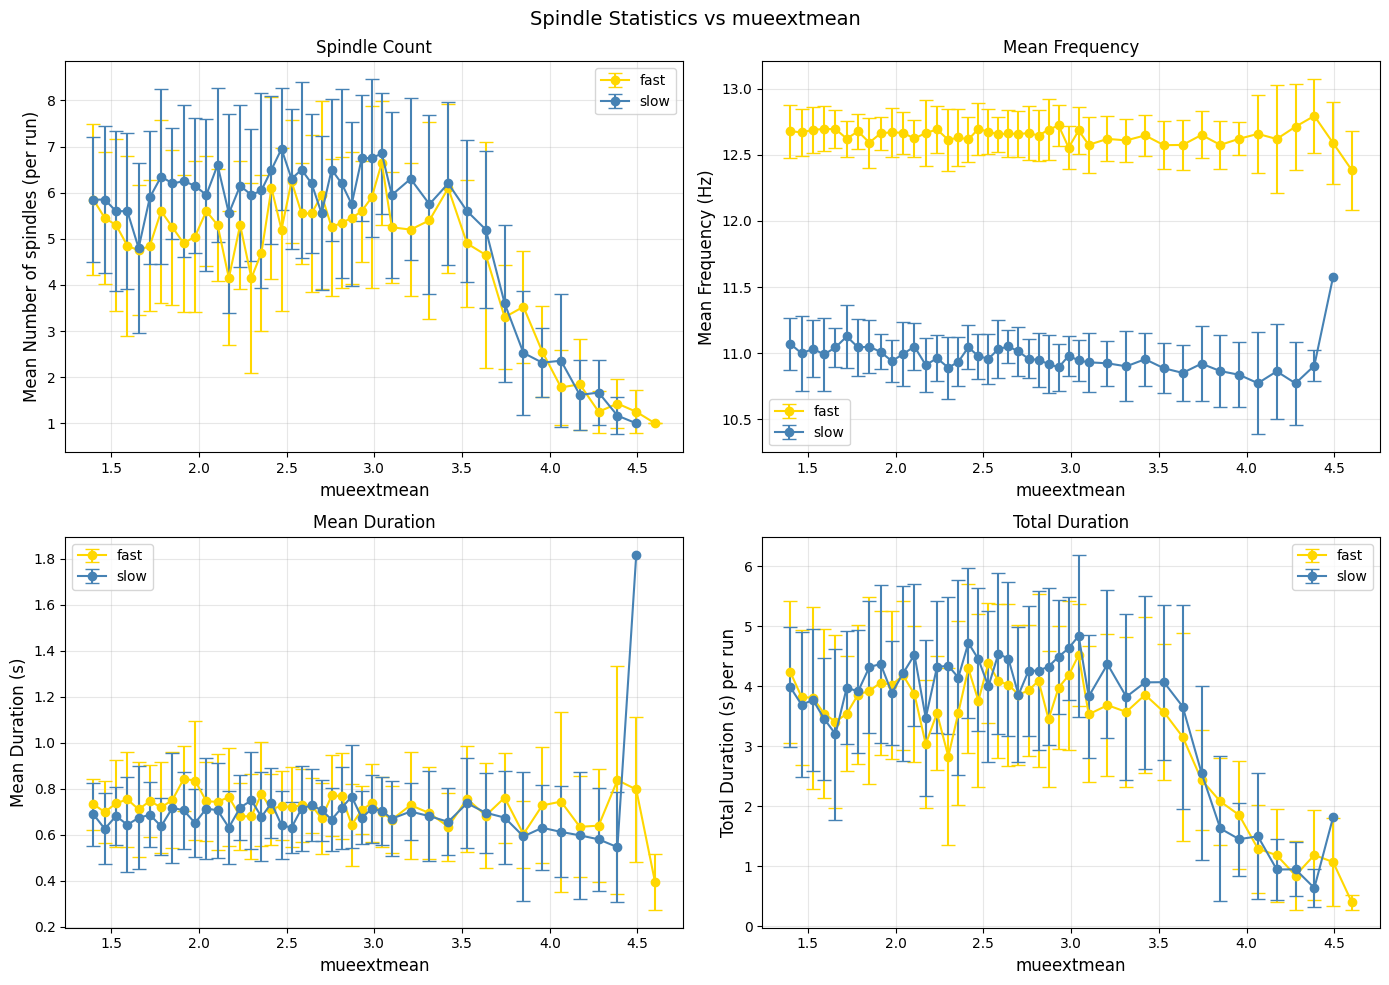


统计摘要（每个 seed 先统计，再对 seed 平均）

FAST 纺锤波:
  mueextmean=1.40: seeds=20, count=5.8±1.6, total_dur=4.24±1.18s, freq=12.68±0.20Hz, dur=0.732±0.112s, phase=-0.330±0.551rad
  mueextmean=1.46: seeds=20, count=5.5±1.4, total_dur=3.82±1.13s, freq=12.67±0.18Hz, dur=0.699±0.136s, phase=-0.322±0.544rad
  mueextmean=1.53: seeds=20, count=5.3±1.9, total_dur=3.81±1.52s, freq=12.69±0.18Hz, dur=0.737±0.190s, phase=-0.228±0.636rad
  mueextmean=1.59: seeds=20, count=4.8±2.0, total_dur=3.54±1.41s, freq=12.70±0.17Hz, dur=0.754±0.207s, phase=-0.210±0.542rad
  mueextmean=1.66: seeds=20, count=4.8±1.4, total_dur=3.41±1.44s, freq=12.69±0.14Hz, dur=0.710±0.206s, phase=-0.148±0.474rad
  mueextmean=1.72: seeds=20, count=4.8±1.4, total_dur=3.54±0.96s, freq=12.62±0.14Hz, dur=0.747±0.155s, phase=-0.182±0.455rad
  mueextmean=1.79: seeds=20, count=5.6±2.0, total_dur=3.86±1.16s, freq=12.68±0.13Hz, dur=0.719±0.198s, phase=-0.235±0.516rad
  mueextmean=1.85: seeds=20, count=5.2±1.7, total_dur=3.93±1.56s, freq=12.59±0.19Hz,

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 只需要改这一个参数 ==========
PARAM_TYPE = "mueextmean"   # 可选: "mueextmean", "tau_ou", "tau_se", "cee"
# ======================================

# 根据 PARAM_TYPE 自动生成所有配置
PARAM_CONFIG = {
    "mueextmean": {
        "file": "spindles_mueextmean_explore_valid_limited.csv",
        "xlabel": "mueextmean",
        "save_prefix": "mueextmean",
    },
    "tau_ou": {
        "file": "spindles_tau_ou_explore_valid_limited.csv",
        "xlabel": "tau_ou (ms)",
        "save_prefix": "tau_ou",
    },
    "tau_se": {
        "file": "spindles_tau_se_explore_valid_limited.csv",
        "xlabel": "tau_se (ms)",
        "save_prefix": "tau_se",
    },
    "cee": {
        "file": "spindles_cee_explore_valid_limited.csv",
        "xlabel": "cee",
        "save_prefix": "cee",
    },
}

# 获取当前配置
config = PARAM_CONFIG[PARAM_TYPE]
DATA_FILE = config["file"]
X_LABEL = config["xlabel"]
SAVE_PREFIX = config["save_prefix"]
PARAM_NAME = PARAM_TYPE

print(f"加载文件: {DATA_FILE}")
print(f"分析参数: {PARAM_NAME}")

# ========== 以下代码完全不用改 ==========
df = pd.read_csv(f"data/analysis_data/{DATA_FILE}")

phase_columns = ['phase_at_start', 'phase_at_peak', 'phase_at_end']
phase_labels = ['Start', 'Peak', 'End']
colors = {'fast': 'gold', 'slow': 'steelblue'}

param_values = sorted(df[PARAM_NAME].unique())
print(f"{PARAM_NAME} 值: {param_values}")

def circular_stats(phases):
    if hasattr(phases, 'dropna'):
        phase_clean = phases.dropna().values
    else:
        phase_clean = phases[~np.isnan(phases)]
    if len(phase_clean) == 0:
        return np.nan, np.nan, 0
    mean_phase = circmean(phase_clean, low=-np.pi, high=np.pi)
    std_phase = circstd(phase_clean, low=-np.pi, high=np.pi)
    return mean_phase, std_phase, len(phase_clean)

# 图1：平均相位（一行三列）
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (col, label) in enumerate(zip(phase_columns, phase_labels)):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = df[df['type'] == spindle_type]
        means, stds, vals = [], [], []
        for val in param_values:
            phases = subset[subset[PARAM_NAME] == val][col].dropna().values
            if len(phases) > 0:
                mean_p, std_p, _ = circular_stats(phases)
                means.append(mean_p)
                stds.append(std_p)
                vals.append(val)
        if len(vals) > 0:
            ax.errorbar(vals, means, yerr=stds, fmt='o-', capsize=5,
                        color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Mean Phase (radians)', fontsize=12)
    ax.set_title(f'Phase at {label}', fontsize=12)
    ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle(f'Mean Phase vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 先计算每个 seed 的统计量，再求平均 ==========
seed_stats = df.groupby([PARAM_NAME, 'seed', 'type']).agg(
    total_duration=('duration', 'sum'),
    count=('duration', 'size'),
    mean_freq=('frequency', 'mean'),
    std_freq=('frequency', 'std'),
    mean_duration=('duration', 'mean'),
    std_duration=('duration', 'std'),
).reset_index()

summary_stats = seed_stats.groupby([PARAM_NAME, 'type']).agg(
    mean_total_duration=('total_duration', 'mean'),
    std_total_duration=('total_duration', 'std'),
    mean_count=('count', 'mean'),
    std_count=('count', 'std'),
    mean_freq=('mean_freq', 'mean'),
    std_freq_mean=('mean_freq', 'std'),
    mean_duration=('mean_duration', 'mean'),
    std_duration_mean=('mean_duration', 'std'),
).reset_index()

print("\n按 seed 统计后的结果示例:")
print(seed_stats.head())
print("\n汇总统计示例:")
print(summary_stats.head())

# ========== 图2：四张汇总图（改成 2行 x 2列）==========
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 2行2列，整体更大
axes = axes.flatten()  # 展平方便索引

# 子图1：平均纺锤波数量
ax = axes[0]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_count'], yerr=subset['std_count'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Number of spindles (per run)', fontsize=12)
ax.set_title('Spindle Count', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图2：平均频率
ax = axes[1]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_freq'], yerr=subset['std_freq_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Frequency (Hz)', fontsize=12)
ax.set_title('Mean Frequency', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图3：平均时长
ax = axes[2]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_duration'], yerr=subset['std_duration_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Duration (s)', fontsize=12)
ax.set_title('Mean Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图4：总时长
ax = axes[3]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_total_duration'], yerr=subset['std_total_duration'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Total Duration (s) per run', fontsize=12)
ax.set_title('Total Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Spindle Statistics vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# 打印统计摘要
print("\n" + "="*60)
print("统计摘要（每个 seed 先统计，再对 seed 平均）")
print("="*60)

for spindle_type in ['fast', 'slow']:
    print(f"\n{spindle_type.upper()} 纺锤波:")
    for val in param_values:
        subset = seed_stats[(seed_stats[PARAM_NAME] == val) & (seed_stats['type'] == spindle_type)]
        if len(subset) > 0:
            n_seeds = len(subset)
            mean_count = subset['count'].mean()
            std_count = subset['count'].std()
            mean_total_dur = subset['total_duration'].mean()
            std_total_dur = subset['total_duration'].std()
            mean_freq = subset['mean_freq'].mean()
            std_freq = subset['mean_freq'].std()
            mean_dur = subset['mean_duration'].mean()
            std_dur = subset['mean_duration'].std()
            
            phases = df[(df[PARAM_NAME] == val) & (df['type'] == spindle_type)]['phase_at_peak'].dropna().values
            if len(phases) > 0:
                mean_phase, std_phase, _ = circular_stats(phases)
                print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, total_dur={mean_total_dur:.2f}±{std_total_dur:.2f}s, freq={mean_freq:.2f}±{std_freq:.2f}Hz, dur={mean_dur:.3f}±{std_dur:.3f}s, phase={mean_phase:6.3f}±{std_phase:.3f}rad")
            else:
                print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, total_dur={mean_total_dur:.2f}±{std_total_dur:.2f}s, freq={mean_freq:.2f}±{std_freq:.2f}Hz, dur={mean_dur:.3f}±{std_dur:.3f}s, no valid phase")